In [68]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.datasets import fetch_california_housing
import seaborn as sns 
from sklearn.metrics import r2_score

california = fetch_california_housing() 

In [69]:
# lets check description of dataset
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [70]:
print(california.feature_names)
df = pd.DataFrame(california.data,columns=california.feature_names)
df['Price'] = california.target
df.info()



#summarizing the stats of data 
df.describe()

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


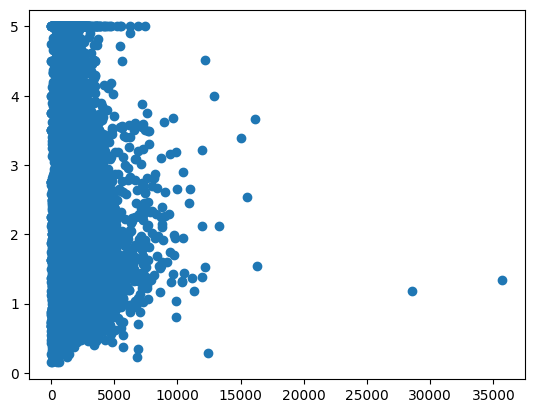

In [71]:
#check missing values
df.isnull().sum()


#EXPLORATORY DATA ANALYSIS EDA  
#correlation

#sns.pairplot(df)
# plt.scatter(df['MedInc'],df['Price'])
# plt.xlabel('median income')
# plt.ylabel('prices')

plt.scatter(df['Population'],df['Price'])
df.corr()

In [72]:
#sns.regplot(x="AveRooms",y= "Price",data = df)

In [73]:
#sns.regplot(x="Latitude",y = "Price",data = df)

In [74]:
#sns.regplot(x="AveOccup",y = "Price",data = df)

In [75]:

#remove outliers 

# from scipy import stats
# z = np.abs(stats.zscore(df['Price']))
# df = df[(z<3)]
df = df[df['Price']<4.5]     #since the price is capped 5.0 hence model cannot understand the differene betwewn 4.8 and 5 so we will remove it 
#act like outliers 

df['Price'] = np.log1p(df['Price'])    #to reduce variance means we will compress large values so that model efficiency increase 

 

In [76]:
#independent and dependent features 

x = df.iloc[:,:-1] # take the whole independent featues except last omne
y = df.iloc[:,-1]



In [77]:
# train test split 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3,random_state=42)




### MODEL TRAINING 


In [78]:
# from sklearn.linear_model import LinearRegression
# regression = LinearRegression()
# regression.fit(x_train,y_train)   

#we will not use linear regression as we do not have linear data 
from sklearn.ensemble import RandomForestRegressor
regression = RandomForestRegressor(n_estimators=300,      #no. of trees 
                                   max_depth=None,
                                   random_state=42,
                                   n_jobs=-1)    #no. of cpu cores used -1 : use all cores 

regression.fit(x_train,y_train)


,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [79]:
from sklearn.model_selection import RandomizedSearchCV   #model optimize  

param_grid ={                                              #try these values for model and find the best one 
    'n_estimators' : [200,300,400],
    'max_depth' : [10,20,None],
    'min_samples_split' : [2,5],
    'min_samples_leaf' : [1,2],
    'max_features' : ['sqrt','log2']
}

# param_grid ={                                              #try these values for model and find the best one 
#     'n_estimators' : [50,100,150],
#     'max_depth' : [5,10,15],
#     'min_samples_split' : [5,10],
#     'min_samples_leaf' : [2,4],
#     'max_features' : ['sqrt']
# }

In [80]:
random_search = RandomizedSearchCV(
    regression,
    param_grid,
    n_iter = 10,
    cv = 3 , 
    verbose=1,
    n_jobs=-1
)
# random_search = RandomizedSearchCV(
#     estimator=regression,
#     param_distributions= param_grid,
#     n_iter = 10,
#     cv = 3 , 
#     verbose=1,
#     random_state = 42,
#     n_jobs=-1
# )

random_search.fit(x_train,y_train)

best_model = random_search.best_estimator_

regression = best_model





Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [81]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(regression,x,y,cv=5,scoring='r2')
print(cv_scores.mean())
print(cv_scores)

0.6041745007897742
[0.59837514 0.60650289 0.70182409 0.51610333 0.59806706]


In [82]:



#on which parameter the model is trained
regression.get_params()



{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 20,
 'max_features': 'log2',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 300,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

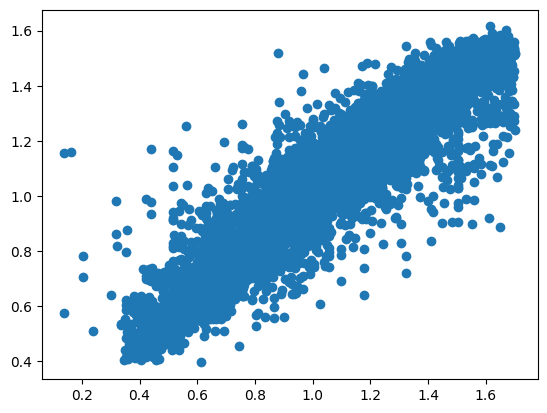

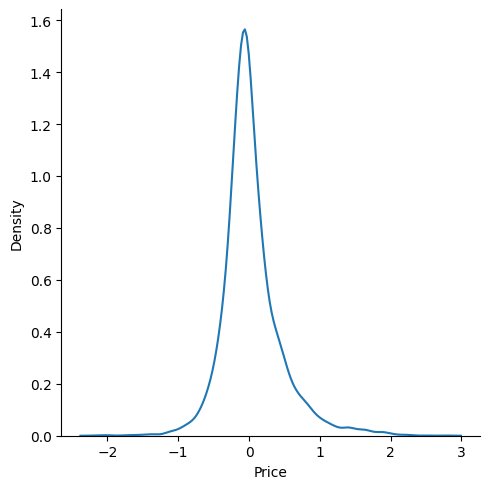

In [83]:
# prediction with test data 
y_pred = regression.predict(x_test)    #prediction of y from x_test 
plt.scatter(y_test,y_pred)

y_pred = np.expm1(y_pred)
y_test = np.expm1(y_test)


residuals = y_test- y_pred
sns.displot(residuals,kind="kde")





0.2833109172963239
0.1751821971031065
0.4185477238059078
0.7975679062566048


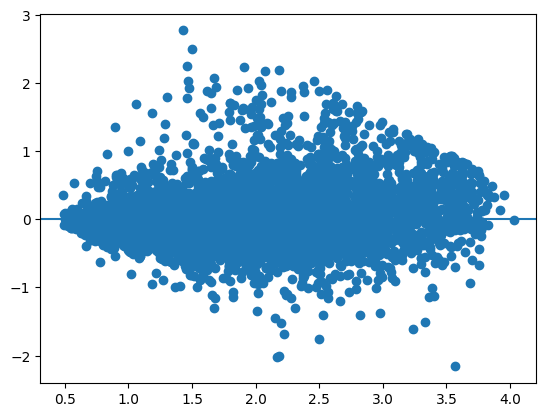

In [84]:
# scatterplot with respect to y_pred and residuals 



plt.scatter(y_pred,residuals)
plt.axhline(y=0)
#uniform distribution 

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))








print(r2_score(y_test, y_pred))





In [85]:
#prediction with new data 
new_data = pd.DataFrame(
    [california.data[2]],
    columns = california.feature_names
)


log_pred = regression.predict(new_data)
final_pre = np.expm1(log_pred)
print(final_pre)
print(california.target)


[3.59850881]
[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [86]:
#pickling for deployment of model file 



# import pickle

# pickle.dump(regression,open('reg_model.pkl','wb'))

# pickled_model = pickle.load(open('reg_model.pkl','rb'))

import joblib 
joblib.dump(regression,"reg_model1.pkl",compress = 3 )
loaded_model = joblib.load("reg_model1.pkl")




In [87]:
log_pred_pick = loaded_model.predict(new_data)
final_pred_pick = np.expm1(log_pred_pick)
final_pred_pick

array([3.59850881])